Model converged in 5 iterations with tol=1e-3


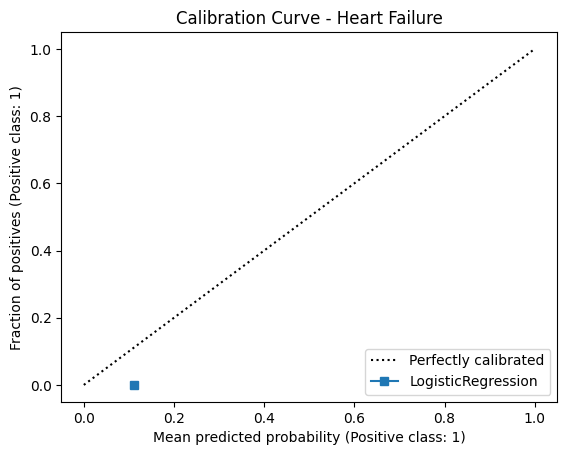

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibrationDisplay

data = pd.read_csv('/kaggle/input/notebooks/hhuhuu/heart-failure-death-prediction/heart-failure-clinical-data_corr.csv')

X = data.drop('DEATH_EVENT', axis=1)

y = data['DEATH_EVENT'].astype(int)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=5)
X_best = selector.fit_transform(X_poly, y)

X_train, X_test, y_train, y_test = train_test_split(X_best, y, test_size=0.3, random_state=42)

model = LogisticRegression(tol=1e-3, max_iter=1000)
model.fit(X_train, y_train)

print(f"Model converged in {model.n_iter_[0]} iterations with tol=1e-3")

CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=5)
plt.title("Calibration Curve - Heart Failure")
plt.show()